In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
import requests
import time

In [2]:
# Load pre-saved gender cache — avoids repeated API calls
import json

with open("gender_cache.json", "r") as f:
    gender_cache = json.load(f)

print("Cache loaded. Total names:", len(gender_cache))

Cache loaded. Total names: 154


In [3]:
# Global plot style — Nobel Prize palette
NOBEL_GOLD = "#C8A951"
NOBEL_NAVY = "#1C2B4A"
NOBEL_CREAM = "#F5F0E8"
NOBEL_DARK = "#1A1A1A"
NOBEL_MUTED = "#8B6914"

plt.rcParams.update({
    "figure.facecolor": NOBEL_CREAM,
    "axes.facecolor": NOBEL_CREAM,
    "axes.edgecolor": NOBEL_DARK,
    "axes.labelcolor": NOBEL_DARK,
    "text.color": NOBEL_DARK,
    "xtick.color": NOBEL_DARK,
    "ytick.color": NOBEL_DARK,
    "font.family": "serif",
})

In [4]:
df =pd.read_csv("nobel_prizes_clean.csv")

In [5]:
df.shape

(995, 33)

In [6]:
df.info

<bound method DataFrame.info of      award_year date_awarded  prize_amount  prize_amount_adjusted  \
0          1901   11/12/1901        150782               10833458   
1          1901   11/14/1901        150782               10833458   
2          1901   12/10/1901        150782               10833458   
3          1901   12/10/1901        150782               10833458   
4          1901   11/12/1901        150782               10833458   
..          ...          ...           ...                    ...   
990        2025    10/7/2025      11000000               11000000   
991        2025    10/6/2025      11000000               11000000   
992        2025   10/13/2025      11000000               11000000   
993        2025    10/9/2025      11000000               11000000   
994        2025    10/6/2025      11000000               11000000   

     laureate_id              known_name                     full_name   sex  \
0          160.0  Jacobus H. van 't Hoff  Jacobus Henricus 

In [7]:
df.describe(include="all") 

,award_year,date_awarded,prize_amount,prize_amount_adjusted,laureate_id,known_name,full_name,sex,portion,sort_order,...,affiliation_city,affiliation_country,affiliation_latitude,affiliation_longitude,wikipedia_url,is_shared,winners_per_year,winners_per_category,is_repeat_winner,country_winner_rank
count,995.000000,995,9.950000e+02,9.950000e+02,995.000000,995,995,752,995.000000,995.000000,...,551,553,542.000000,542.000000,752,995.000000,995.000000,995.000000,995.000000,751.000000
unique,NaN,470,NaN,NaN,NaN,990,990,2,NaN,NaN,...,165,28,NaN,NaN,747,NaN,NaN,NaN,NaN,NaN
top,NaN,11/14/1946,NaN,NaN,NaN,Marie Curie,"Marie Curie, née Skłodowska",male,NaN,NaN,...,"New York, NY",USA,NaN,NaN,https://en.wikipedia.org/wiki/Marie_Curie,NaN,NaN,NaN,NaN,NaN
freq,NaN,7,NaN,NaN,NaN,2,2,703,NaN,NaN,...,34,262,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
mean,1974.826131,NaN,3.959410e+06,8.030975e+06,518.186935,NaN,NaN,NaN,0.611390,1.510553,...,NaN,NaN,44.085730,-37.420338,NaN,0.655276,9.297487,184.877387,0.005025,40.161119
std,35.009814,NaN,4.275932e+06,4.101196e+06,307.864180,NaN,NaN,NaN,0.292668,0.702567,...,NaN,NaN,10.968079,58.555238,NaN,0.475517,2.898335,53.419236,0.070745,52.565940
min,1901.000000,NaN,1.149350e+05,3.006134e+06,1.000000,NaN,NaN,NaN,0.250000,1.000000,...,NaN,NaN,-37.797306,-123.120129,NaN,0.000000,1.000000,99.000000,0.000000,1.000000
25%,1950.000000,NaN,1.727600e+05,3.923237e+06,249.500000,NaN,NaN,NaN,0.333333,1.000000,...,NaN,NaN,40.014316,-78.550003,NaN,0.000000,7.000000,122.000000,0.000000,5.000000
50%,1980.000000,NaN,8.800000e+05,6.845037e+06,505.000000,NaN,NaN,NaN,0.500000,1.000000,...,NaN,NaN,42.444089,-7.703068,NaN,1.000000,10.000000,200.000000,0.000000,15.000000
75%,2004.000000,NaN,9.000000e+06,1.160359e+07,780.500000,NaN,NaN,NaN,1.000000,2.000000,...,NaN,NaN,51.510235,7.821994,NaN,1.000000,12.000000,230.000000,0.000000,53.000000


In [8]:
df.columns

Index(['award_year', 'date_awarded', 'prize_amount', 'prize_amount_adjusted',
       'laureate_id', 'known_name', 'full_name', 'sex', 'portion',
       'sort_order', 'motivation', 'category', 'birth_date', 'birth_city',
       'birth_country', 'birth_latitude', 'birth_longitude', 'death_date',
       'death_city', 'death_country', 'death_latitude', 'death_longitude',
       'affiliation_name', 'affiliation_city', 'affiliation_country',
       'affiliation_latitude', 'affiliation_longitude', 'wikipedia_url',
       'is_shared', 'winners_per_year', 'winners_per_category',
       'is_repeat_winner', 'country_winner_rank'],
      dtype='str')

## 1) Setup & Data Audit

The dataset contains one row per Nobel Prize laureate across all categories 
from 1901 to the present. It includes demographic information, affiliation, 
prize share, and a pre-computed `is_repeat_winner` flag.

Everything loaded cleanly. The one problem worth flagging early: gender is 
missing for a significant chunk of the data. That's where we start.

## 2) The missing data problem

Gender is missing for a significant portion of the dataset — and that's 
not a small inconvenience. If the gaps are concentrated in specific 
categories, any analysis that ignores them would be quietly skewed 
toward the categories with better documentation.

Before touching anything else, I want to know: how much is missing, and where?

In [9]:
# How much is missing overall?
total_missing = df["sex"].isna().sum()
percent_missing = df["sex"].isna().mean() * 100

print("Total missing:", total_missing)
print("Percentage missing:", round(percent_missing, 2), "%")

Total missing: 243
Percentage missing: 24.42 %


In [10]:
# Where is it missing — by category?
missing_by_category = df["sex"].isna().groupby(df["category"]).sum()
print(missing_by_category)

category
Chemistry                  2
Economic Sciences         46
Literature                 3
Peace                     27
Physics                   87
Physiology or Medicine    78
Name: sex, dtype: int64


In [11]:
## Are the missing entries all individuals — or are organizations hiding in here?

df[
    (df["sex"].isna()) &
    (df["category"] != "Peace")
][["full_name", "category"]].head(15)

,full_name,category
366,Ronald George Wreyford Norrish,Chemistry
369,Hans Albrecht Bethe,Physics
370,Ragnar Granit,Physiology or Medicine
371,Haldan Keffer Hartline,Physiology or Medicine
372,George Wald,Physiology or Medicine
376,Luis Walter Alvarez,Physics
377,Robert W. Holley,Physiology or Medicine
378,Har Gobind Khorana,Physiology or Medicine
379,Marshall W. Nirenberg,Physiology or Medicine
385,Murray Gell-Mann,Physics


### What the Audit Tells Us

- Gender is missing for **243 laureates** — around  24% of the dataset
- The gap isn't evenly spread. It clusters in specific categories, which means dropping those rows wouldn't just reduce the data, it would also distort it hence risking drawing conclusions from a biased sample.
- All non-Peace entries with missing gender turned out to be individuals, not organizations. That matters because it means name-based inference is actually applicable here.


**Decision:** Instead of ignoring the gap or blindly filling it, I split the analysis 
into two tracks:
- **Track 1** — observed gender only, no assumptions (conservative baseline)
- **Track 2** — gender inferred via the Genderize API at 90% confidence (primary analysis)

If findings stable across both tracks, they are treated as robust.  
If findings shift, they are flagged and treated with caution.

## 3) Track 1: Observed Gender Only

The simplest starting point, only laureates where gender is already 
recorded. No inference, no assumptions. Just what the data shows as-is.

This gives me a baseline to return to later when I need to test whether inference actually changed anything.

In [12]:
df_obs = df[df["sex"].notna()].copy()

In [13]:
# Track 1 — observed gender only
print("Track 1 shape:", df_obs.shape)
print("\nGender counts:")
print(df_obs["sex"].value_counts())

Track 1 shape: (752, 33)

Gender counts:
sex
male      703
female     49
Name: count, dtype: int64


In [14]:
# Category counts in Track 1
df_obs["category"].value_counts()

category
Chemistry                 198
Physiology or Medicine    154
Physics                   143
Literature                119
Peace                      85
Economic Sciences          53
Name: count, dtype: int64

In [15]:
# Category × sex counts
df_obs.groupby(["category", "sex"]).size()

category                sex   
Chemistry               female      8
                        male      190
Economic Sciences       female      1
                        male       52
Literature              female     17
                        male      102
Peace                   female     12
                        male       73
Physics                 female      3
                        male      140
Physiology or Medicine  female      8
                        male      146
dtype: int64

In [16]:
# Repeat winner summary by category and sex
summary = (
    df_obs
    .groupby(["category", "sex"])
    .agg(
        count=("is_repeat_winner", "size"),
        repeat_rate=("is_repeat_winner", "mean")
    )
)
summary

count  repeat_rate
category               sex                       
Chemistry              female      8     0.125000
                       male      190     0.010526
Economic Sciences      female      1     0.000000
                       male       52     0.000000
Literature             female     17     0.000000
                       male      102     0.000000
Peace                  female     12     0.000000
                       male       73     0.013699
Physics                female      3     0.000000
                       male      140     0.007143
Physiology or Medicine female      8     0.000000
                       male      146     0.000000

### 3.1) Track 1 Takeaway

Women are underrepresented across all categories in the observed data. 
Female sample sizes in Physics and Economic Sciences are too small to draw 
any meaningful conclusions from repeat winner rates.

That's also the deeper problem with stopping here. The missing 24% isn't 
spread evenly — it clusters in specific categories, which means Track 1 
is not a neutral baseline. It's a skewed one.


## 4) Track 2: Gender Inference

Track 1 gave me the observed picture — but 24% of gender values are missing, 
and that missingness is uneven across categories. I needed to test whether the findings 
are sensitive to this gap, if I filled some of it in.

**Inference conditions:**
- Only applied to non-Peace categories since Peace Prize winners include 
  organizations and collective bodies which cannot be gender-inferred from a first name.
  All missing Peace entries are handled separately.
- Only where a first name can be extracted — some entries contain 
  initials only, incomplete names, or formatting issues are excluded to avoid 
  feeding ambiguous inputs to the API.  Garbage in, garbage out.
- Only where the Genderize API returns ≥ 90% confidence so all low confidence 
  results are discarded rather than accepted, to minimize incorrect assignments.
- Organizations and ambiguous entries are excluded automatically as a 
  result of the rules above.

This aproach serves as a robustness check so if findings remain consistent whether or not we include inferred gender, 
we can treat those findings as stable, however If findings shift, we know they are 
sensitive to the missing data and must be interpreted with caution.

> ⚠️ **Peace Prize entries are excluded from all subsequent loop classification 
> and growth analysis.** The mix of individuals and organizations in that category 
> makes it structurally incomparable to the scientific categories this analysis 
> is built around.

### 4.1) Gender Inference via Genderize API

To infer gender for eligible missing entries, I use the 
[Genderize.io](https://genderize.io) API. It takes a first name as input 
and returns a predicted gender along with a probability score and the number 
of data points the prediction is based on.

Example response:
`{'name': 'Marie', 'gender': 'female', 'probability': 0.99, 'count': 817989}`

The first step is extracting the first name from each laureate's full name.

In [17]:
# Extract first name
df["first_name"] = df["full_name"].str.strip().str.split().str[0]
df[["full_name", "first_name"]].head(10)

,full_name,first_name
0,Jacobus Henricus van 't Hoff,Jacobus
1,Sully Prudhomme,Sully
2,Jean Henry Dunant,Jean
3,Frédéric Passy,Frédéric
4,Wilhelm Conrad Röntgen,Wilhelm
5,Emil Adolf von Behring,Emil
6,Hermann Emil Fischer,Hermann
7,Christian Matthias Theodor Mommsen,Christian
8,Élie Ducommun,Élie
9,Charles Albert Gobat,Charles


In [18]:
# Defin eligible rows for inference
mask_infer = (
    df["sex"].isna() & 
    df["first_name"].notna() &
    (df["category"] != "Peace")
)

print("Rows eligible for inference:", mask_infer.sum())
print("Unique names to query:", df.loc[mask_infer, "first_name"].nunique())

Rows eligible for inference: 216
Unique names to query: 154


In [19]:
# API call — Genderize.io
# Commented out — cache loaded from gender_cache.json at the top of the notebook
# Uncomment and run only if cache is lost

# names_to_infer = df.loc[mask_infer, "first_name"].unique()
# gender_cache = {}
# for i, name in enumerate(names_to_infer, start=1):
#     try:
#         url = f"https://api.genderize.io?name={name}"
#         r = requests.get(url)
#         data = r.json()
#         gender_cache[name] = {
#             "gender": data.get("gender"),
#             "probability": data.get("probability"),
#             "count": data.get("count")
#         }
#         if i % 10 == 0:
#             print(f"{i}/{len(names_to_infer)} done")
#         time.sleep(1)
#     except Exception as e:
#         gender_cache[name] = {
#             "gender": None,
#             "probability": None,
#             "count": None
#         }
# print("Done. Total names queried:", len(gender_cache))

print("Cache already loaded. Total names:", len(gender_cache))

Cache already loaded. Total names: 154


In [20]:
# Apply inference with 90% confidence threshold
THRESHOLD = 0.90
df["sex_filled"] = df["sex"]

def infer_from_cache(first_name):
    info = gender_cache.get(first_name, None)
    if not info:
        return None
    g = info.get("gender")
    p = info.get("probability")
    if (g is not None) and (p is not None) and (p >= THRESHOLD):
        return g
    return None

df.loc[mask_infer, "sex_filled"] = df.loc[mask_infer, "first_name"].apply(infer_from_cache)
df["sex_filled"] = df["sex_filled"].replace({None: pd.NA}) #cleanup line to avoid bugs.

print("Original sex counts:")
print(df["sex"].value_counts(dropna=False))
print("\nFilled sex counts:")
print(df["sex_filled"].value_counts(dropna=False))

Original sex counts:
sex
male      703
NaN       243
female     49
Name: count, dtype: int64

Filled sex counts:
sex_filled
male      849
NaN        93
female     53
Name: count, dtype: int64


In [21]:
print(len(gender_cache))
print(df["sex_filled"].value_counts(dropna=False))

154
sex_filled
male      849
NaN        93
female     53
Name: count, dtype: int64


### Saving so we do not run api each time.

In [22]:
import json

with open("gender_cache.json", "w") as f:
    json.dump(gender_cache, f)

print("Cache saved. Total names:", len(gender_cache))

Cache saved. Total names: 154


In [23]:
# Spot check — manual verification of 10 inferred entries
spot_check = df[
    df["sex"].isna() &
    df["sex_filled"].notna()
][["full_name", "first_name", "sex_filled", "category"]].sample(10, random_state=42)

print(spot_check.to_string())

                         full_name     first_name sex_filled           category
588             Harry M. Markowitz          Harry       male  Economic Sciences
420  Wassily Wassilyevich Leontief        Wassily       male  Economic Sciences
755              Theodor W. Hänsch        Theodor       male            Physics
608                Georges Charpak        Georges       male            Physics
601        Pierre-Gilles de Gennes  Pierre-Gilles       male            Physics
465       John Hasbrouck Van Vleck           John       male            Physics
572               Jack Steinberger           Jack       male            Physics
922                  James Peebles          James       male            Physics
579                Trygve Haavelmo         Trygve       male  Economic Sciences
638            Robert E. Lucas Jr.         Robert       male  Economic Sciences


### Inference Results

I spot checked 10 of the inferred entries manually — all assignments 
looked correct. The 90% confidence threshold filters out ambiguous cases.

Next I compare Track 1 and Track 2 directly to see what actually changed.

## 5) Track 1 vs Track 2: Did Inference Change the Story?
Comparing the two tracks to identify which findings are stable across both, and which shifted as a result of inference.



### 5.1)  Building df_filled — Track 2 dataset

In [24]:
df_filled = df[df["sex_filled"].notna()].copy()
print("Track 2 shape:", df_filled.shape)

Track 2 shape: (902, 35)


### 5.2) Female counts per track

In [26]:
# Female counts per category in each track
female_t1 = (
    df_obs[df_obs["sex"] == "female"]
    .groupby("category")
    .size()
    .rename("Track 1 (observed)")
)

female_t2 = (
    df_filled[df_filled["sex_filled"] == "female"]
    .groupby("category")
    .size()
    .rename("Track 2 (with inference)")
)

### 5.3) Comparison table

In [28]:
# How much did inference change the female counts?
comparison = pd.DataFrame([female_t1, female_t2]).T.fillna(0).astype(int)
comparison["difference"] = comparison["Track 2 (with inference)"] - comparison["Track 1 (observed)"]
comparison["inference_added_%"] = (
    (comparison["difference"] / comparison["Track 1 (observed)"].replace(0, pd.NA)) * 100
).round(1)

print(comparison.sort_values("difference", ascending=False))

                        Track 1 (observed)  Track 2 (with inference)  \
category                                                               
Physiology or Medicine                   8                        11   
Literature                              17                        18   
Economic Sciences                        1                         1   
Chemistry                                8                         8   
Peace                                   12                        12   
Physics                                  3                         3   

                        difference  inference_added_%  
category                                               
Physiology or Medicine           3               37.5  
Literature                       1                5.9  
Economic Sciences                0                0.0  
Chemistry                        0                0.0  
Peace                            0                0.0  
Physics                        

### 5.4) Graph A: Track 1 vs Track 2 comparison

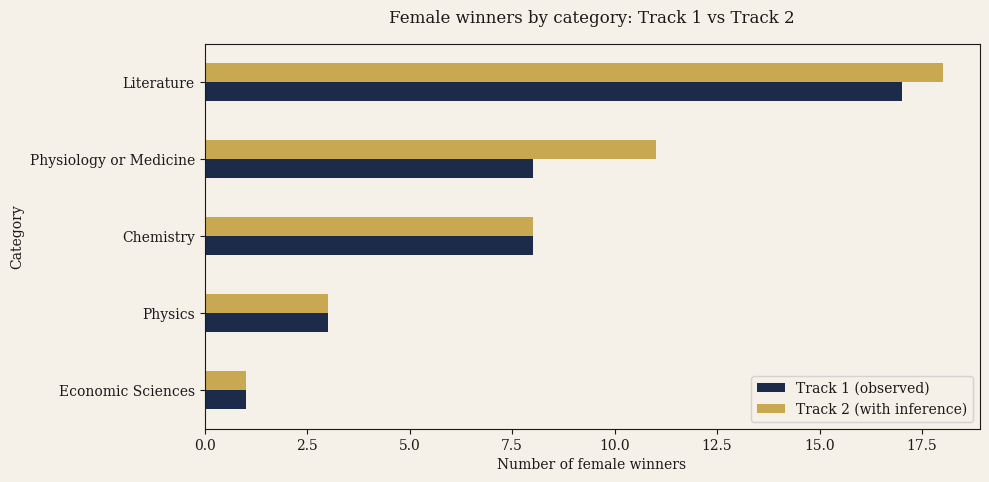

In [29]:
# Graph — Female counts Track 1 vs Track 2 
categories_to_include = [
    "Literature", "Physiology or Medicine", "Chemistry", 
    "Physics", "Economic Sciences"
]

female_compare = pd.DataFrame({
    "Track 1 (observed)": female_t1,
    "Track 2 (with inference)": female_t2
}).fillna(0).astype(int)


# Exclude Peace
female_compare = female_compare[
    female_compare.index.isin(categories_to_include)
]

female_compare = female_compare.sort_values(
    "Track 2 (with inference)", ascending=True
)

ax = female_compare.plot(
    kind="barh",
    figsize=(10, 5),
    color=[NOBEL_NAVY, NOBEL_GOLD]
)
ax.set_title("Female winners by category: Track 1 vs Track 2", pad=15)
ax.set_xlabel("Number of female winners")
ax.set_ylabel("Category")
ax.legend()
plt.savefig("03_female_counts_track1_vs_track2.png")
plt.show()

### 5.5) What Changed — and What Didn't

| Category | Track 1 | Track 2 | Difference | Inference Added |
|---|---|---|---|---|
| Physiology or Medicine | 8 | 11 | +3 | +37.5% |
| Literature | 17 | 18 | +1 | +5.9% |
| Chemistry | 8 | 8 | 0 | 0% |
| Economic Sciences | 1 | 1 | 0 | 0% |
| Physics | 3 | 3 | 0 | 0% |




Inference had a meaningful impact in only one category: Physiology or Medicine 
gained 3 additional female winners — a 37.5% increase over the observed count. 
That's significant enough that any conclusion I draw about Medicine needs a 
clear warning attached to it.

For everything else — Literature gained one entry (5.9%), and Chemistry, Physics, 
and Economic Sciences showed no change at all. Their Track 2 counts are identical 
to Track 1, meaning those findings don't depend on inference. What they do depend 
on is having enough data to say anything meaningful — and in Physics and Economic 
Sciences, that remains a problem regardless of which track I use.

Note: Peace appears in the raw counts above but is excluded from all subsequent 
interpretation — loop classification, growth analysis, and conclusions. 
This was decided earlier: the mix of individuals and organizations in that 
category makes it structurally incomparable to the scientific categories 
this analysis is built around. 

**Analytical decision:** From here I use Track 2 as the primary dataset. Where Medicine-specific findings 
appear, I flag them explicitly.

## 6) Growth Over Time

Having established who was recognized and confirmed our findings are stable 
across both tracks, we now ask the central question: *did recognition grow?*

We measure female wins per decade and female recognition rate per category 
to identify whether recognition compounded, stagnated, or remained sporadic 
after the first female winner appeared in each field.

### 6.1) Graph B: The Overall Picture

Before looking at how things changed over time, here is where things stand overall: 
Gender distribution across all scientific categories in Track 2.

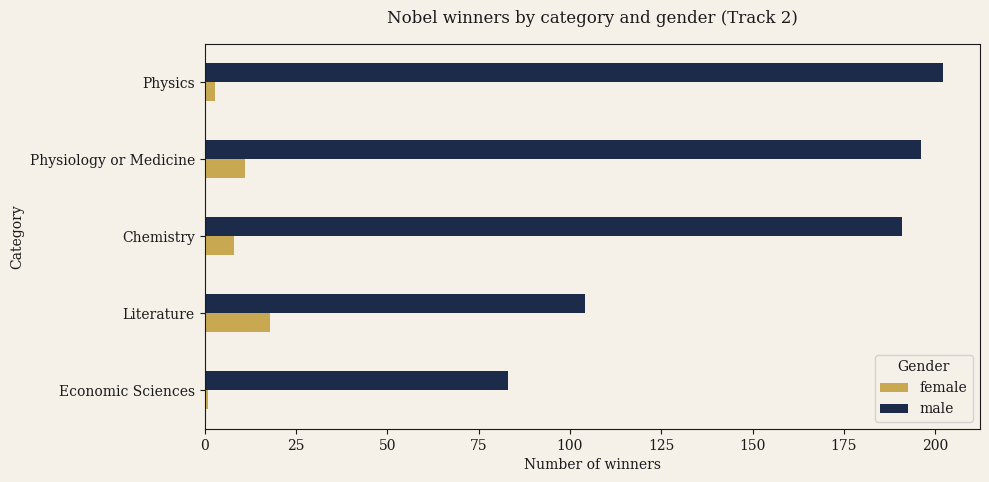

In [30]:
categories_to_plot_dist = [
    "Literature", "Physiology or Medicine", "Chemistry", 
    "Physics", "Economic Sciences"
]

counts_by_cat_sex = (
    df_filled[df_filled["category"].isin(categories_to_plot_dist)]
    .groupby(["category", "sex_filled"])
    .size()
    .unstack(fill_value=0)
)

cols = [c for c in ["female", "male"] if c in counts_by_cat_sex.columns]
counts_by_cat_sex = counts_by_cat_sex[cols].sort_values("male", ascending=True)

ax = counts_by_cat_sex.plot(
    kind="barh",
    figsize=(10, 5),
    color=[NOBEL_GOLD, NOBEL_NAVY]
)
ax.set_title("Nobel winners by category and gender (Track 2)", pad=15)
ax.set_xlabel("Number of winners")
ax.set_ylabel("Category")
ax.legend(title="Gender")
plt.savefig("01_gender_by_category_track2.png")
plt.show()

The gap is stark across every category. Literature shows the highest female 
representation by far. Chemistry and Physiology or Medicine sit in the middle. 
Physics and Economic Sciences are near-zero on the female side
— a pattern that will matter significantly when I look at growth over time.

### 6.2) Female Wins Per Decade

How did female recognition evolve across decades in each field?

In [31]:
# Assign decade
df_filled["decade"] = (df_filled["award_year"] // 10) * 10

# Female winners per decade per category
female_by_decade = (
    df_filled[df_filled["sex_filled"] == "female"]
    .groupby(["decade", "category"])
    .size()
    .reset_index(name="female_count")
)

# Total winners per decade per category
total_by_decade = (
    df_filled
    .groupby(["decade", "category"])
    .size()
    .reset_index(name="total_count")
)

# Merge and compute female recognition rate
decade_summary = female_by_decade.merge(
    total_by_decade, on=["decade", "category"], how="right"
)
decade_summary["female_count"] = decade_summary["female_count"].fillna(0).astype(int)
decade_summary["female_rate"] = (
    decade_summary["female_count"] / decade_summary["total_count"]
).round(3)

print(decade_summary.sort_values(["category", "decade"]).to_string())

    decade                category  female_count  total_count  female_rate
0     1900               Chemistry             0            9        0.000
5     1910               Chemistry             1            8        0.125
10    1920               Chemistry             0           10        0.000
15    1930               Chemistry             1           13        0.077
20    1940               Chemistry             0            9        0.000
25    1950               Chemistry             0           14        0.000
30    1960               Chemistry             1           15        0.067
36    1970               Chemistry             0           15        0.000
42    1980               Chemistry             0           20        0.000
48    1990               Chemistry             0           18        0.000
54    2000               Chemistry             1           25        0.040
60    2010               Chemistry             1           27        0.037
66    2020               

### 6.3) Time to First Female Winner

In [32]:
# Time to first female winner per category
first_award_year = (
    df_filled
    .groupby("category")["award_year"]
    .min()
    .rename("category_start")
)

first_female_year = (
    df_filled[df_filled["sex_filled"] == "female"]
    .groupby("category")["award_year"]
    .min()
    .rename("first_female_win")
)

time_to_first = pd.DataFrame([first_award_year, first_female_year]).T
time_to_first["years_to_first_woman"] = (
    time_to_first["first_female_win"] - time_to_first["category_start"]
)

print(time_to_first.sort_values("years_to_first_woman").to_string())

                        category_start  first_female_win  years_to_first_woman
category                                                                      
Physics                           1901              1903                     2
Peace                             1901              1905                     4
Literature                        1901              1909                     8
Chemistry                         1901              1911                    10
Economic Sciences                 1969              2009                    40
Physiology or Medicine            1901              1947                    46


### 6.4) Graph C: Growth chart

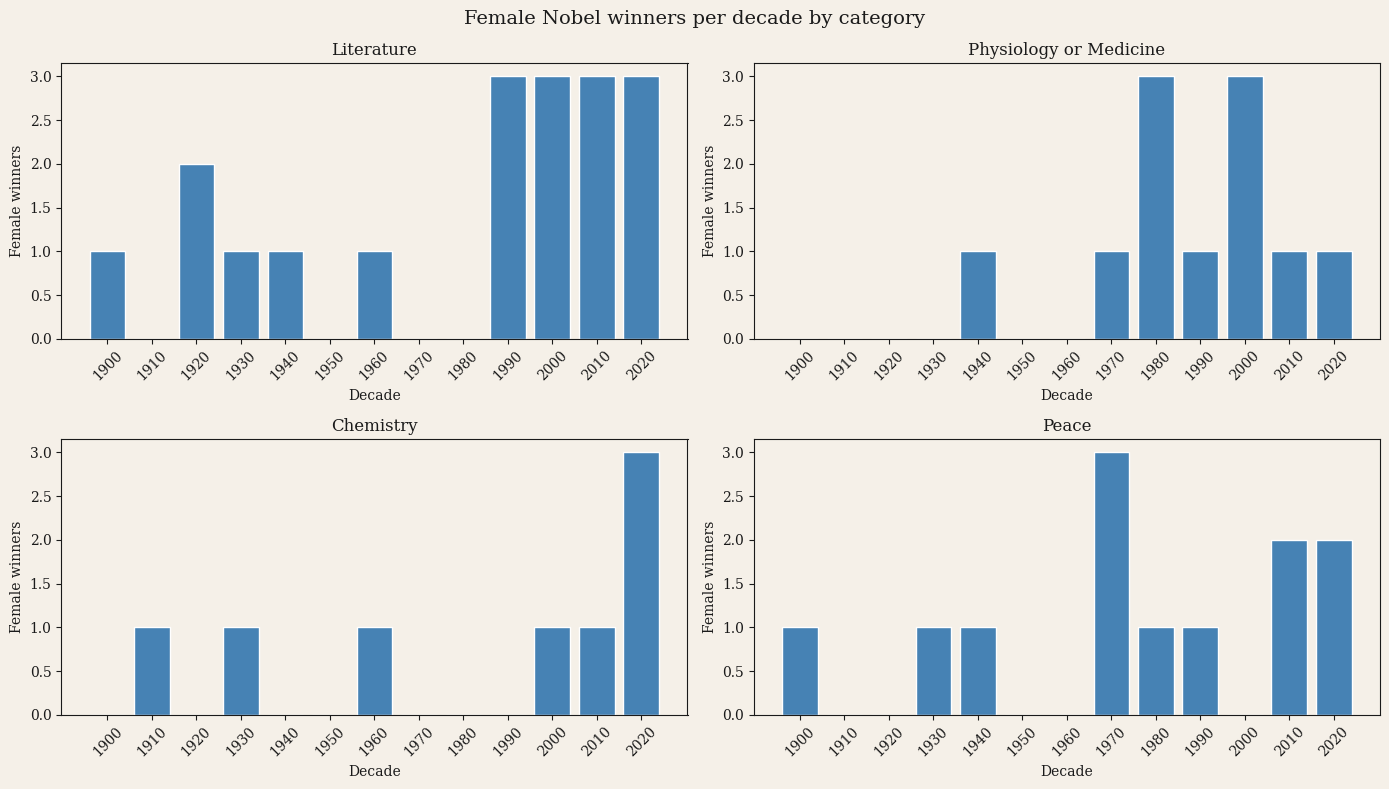

<Figure size 640x480 with 0 Axes>

In [33]:
# Graph 2 — Female wins per decade by category
categories_to_plot = [
    "Literature", "Physiology or Medicine", "Chemistry", "Peace"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(categories_to_plot):
    cat_data = decade_summary[
        decade_summary["category"] == cat
    ].sort_values("decade")
    ax = axes[i]
    ax.bar(
        cat_data["decade"],
        cat_data["female_count"],
        width=8,
        color="steelblue",
        edgecolor="white"
    )
    ax.set_title(cat, fontsize=12)
    ax.set_xlabel("Decade")
    ax.set_ylabel("Female winners")
    ax.set_xticks(cat_data["decade"])
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Female Nobel winners per decade by category", fontsize=14)
plt.tight_layout()
plt.savefig("05_female_wins_per_decade.png")
plt.show()
for i, cat in enumerate(categories_to_plot):
    cat_data = decade_summary[
        decade_summary["category"] == cat
    ].sort_values("decade", ascending=True)
    ax = axes[i]
    ax.barh(
        cat_data["decade"].astype(str),
        cat_data["female_count"],
        color=NOBEL_GOLD,
        edgecolor=NOBEL_DARK,
        height=0.6
    )
    ax.set_title(cat, fontsize=12)
    ax.set_xlabel("Female winners")
    ax.set_ylabel("Decade")
plt.savefig("05_female_wins_per_decade.png")
plt.show()

### 6.5) Time to First Female Winner

| Category | First Award | First Woman | Years Wait |
|---|---|---|---|
| Physics | 1901 | 1903 | 2 |
| Peace | 1901 | 1905 | 4 |
| Literature | 1901 | 1909 | 8 |
| Chemistry | 1901 | 1911 | 10 |
| Economic Sciences | 1969 | 2009 | 40 |
| Physiology or Medicine | 1901 | 1947 | 46 |

Physics and Chemistry recognized women within the first decade of the prize,
yet both produced weakest growth patterns in the dataset. 
Physiology or Medicine waited 46 years for its first female winner, yet shows the most sustained 
growth trajectory of any STEM field post-1970.

> Peace is included for reference. Its pattern is not interpreted within 
> the recognition-growth framework — see earlier note for reasoning.

**Early recognition did not predict how the field responded. What matters 
is what followed.**

### 6.6) Growth Patterns by Category

**Literature — Strong Loop ✅**
Scattered wins in the early decades, then something shifted around 1990. 
Since then — 3 female winners every single decade without exception. 
By the 2020s, half of all Literature prizes went to women. 
This is the only field where recognition genuinely compounded.

**Physiology or Medicine — Lagged Loop ⏳**
46 years of silence after the prize was established, then a slow but real 
build from 1980 onward. It never reaches Literature's consistency — but the 
direction is clear. The only STEM field that shows genuine sustained growth.
*Inference-sensitive: +37.5% female count added by Track 2. Read with caution.*

**Chemistry — Broken Loop ⚠️**
One win here, one win there, decades of nothing in between. The 2020s 
brought 3 female winners — the most in any single decade — but it's too 
soon to call that a trend rather than a cluster.

**Physics — Broken Loop ❌**
Three female winners in 120 years. 1903, 1963, 2018. 
No two consecutive decades with a female winner. 
The field that recognized a woman second — right after Peace — 
produced the least growth of any category.

**Economic Sciences — Insufficient Data ❓**
One female winner since the category was established in 1969. 
Nothing before, nothing after. Too little data to say anything meaningful.

**Peace — Excluded**
Peace Prize patterns exist — but they can't be compared to scientific 
categories within this framework. See earlier note.

# 7) Repeat Recognition: Are the Same Women Winning?

The previous section showed whether female wins increased over time. 
This section asks a different question: when women did win, 
were they new faces — or the same ones returning?

A field can show growth in numbers while recognition stays 
concentrated in one or two individuals. That's a very different 
story from genuine broadening of representation.

⚠️ Female sample sizes in Physics and Economic Sciences are too 
small to draw any meaningful conclusions here. Chemistry, Literature, 
and Physiology or Medicine only.

## 7.1) Repeat winner summary — table format

In [34]:
# Repeat winner rate by category and gender (Track 2)
repeat_rate = (
    df_filled.groupby(["category", "sex_filled"])["is_repeat_winner"]
    .mean()
    .unstack()
)

counts = (
    df_filled.groupby(["category", "sex_filled"])
    .size()
    .unstack(fill_value=0)
)

sort_col = "male" if "male" in repeat_rate.columns else repeat_rate.columns[0]
repeat_rate = repeat_rate.sort_values(sort_col, ascending=True)

# Repeat winner summary — table format
repeat_summary = pd.DataFrame({
    "Female winners": counts.get("female", pd.Series(dtype=float)),
    "Female repeat rate": repeat_rate.get("female", pd.Series(dtype=float)).round(3),
    "Male winners": counts.get("male", pd.Series(dtype=float)),
    "Male repeat rate": repeat_rate.get("male", pd.Series(dtype=float)).round(3),
})

print(repeat_summary.to_string())

                        Female winners  Female repeat rate  Male winners  Male repeat rate
category                                                                                  
Chemistry                            8               0.125           191             0.010
Economic Sciences                    1               0.000            83             0.000
Literature                          18               0.000           104             0.000
Peace                               12               0.000            73             0.014
Physics                              3               0.000           202             0.005
Physiology or Medicine              11               0.000           196             0.000


## 7.2) Graph D:Repeat winner summary 
The numbers tell the story — but the bubble chart shows it. 

Each bubble represents a category. Size reflects the number of winners. 
Position on the x-axis shows the repeat rate.

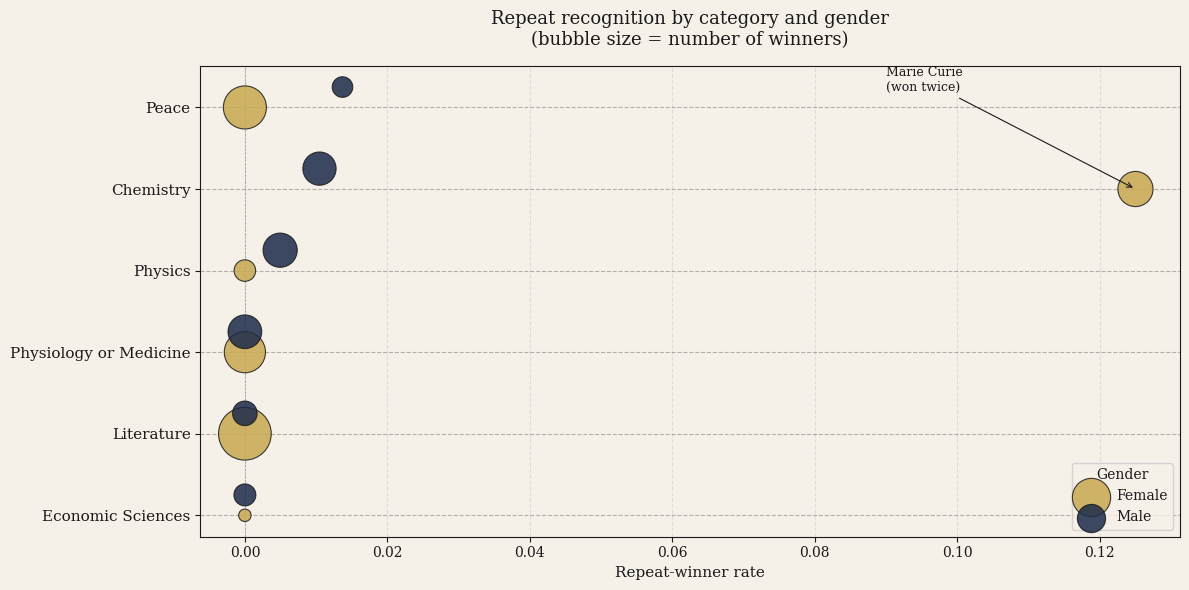

In [35]:
# Bubble chart — repeat rate vs category, sized by winner count
categories = repeat_rate.index.tolist()
y_pos = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(12, 6))

# Female bubbles
female_rates = repeat_rate.get("female", pd.Series(dtype=float)).reindex(categories).fillna(0)
female_counts = counts.get("female", pd.Series(dtype=float)).reindex(categories).fillna(0)

ax.scatter(
    female_rates,
    y_pos,
    s=female_counts * 80,
    color=NOBEL_GOLD,
    alpha=0.85,
    label="Female",
    edgecolors=NOBEL_DARK,
    linewidth=0.8,
    zorder=3
)

# Male bubbles
male_rates = repeat_rate.get("male", pd.Series(dtype=float)).reindex(categories).fillna(0)
male_counts = counts.get("male", pd.Series(dtype=float)).reindex(categories).fillna(0)

ax.scatter(
    male_rates,
    y_pos + 0.25,
    s=male_counts * 3,
    color=NOBEL_NAVY,
    alpha=0.85,
    label="Male",
    edgecolors=NOBEL_DARK,
    linewidth=0.8,
    zorder=3
)

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=11)
ax.set_xlabel("Repeat-winner rate", fontsize=11)
ax.set_title("Repeat recognition by category and gender\n(bubble size = number of winners)", 
             pad=15, fontsize=13)
ax.legend(title="Gender", fontsize=10)
ax.axvline(x=0, color=NOBEL_DARK, linewidth=0.5, linestyle="--", alpha=0.4)
ax.grid(axis="x", linestyle="--", alpha=0.3)

#Marie Curie annotation
chem_idx = categories.index("Chemistry")
ax.annotate(
    "Marie Curie\n(won twice)",
    xy=(0.125, chem_idx),
    xytext=(0.09, chem_idx + 1.2),
    fontsize=9,
    color=NOBEL_DARK,
    arrowprops=dict(arrowstyle="->", color=NOBEL_DARK, lw=0.8)
)
ax.grid(axis="y", linestyle="--", alpha=0.3, color=NOBEL_DARK)
plt.tight_layout()
plt.savefig("04_repeat_rate_bubble.png")
plt.show()

### What This Shows

No woman has won more than once in any category — except Marie Curie, 
who won Physics in 1903 and Chemistry in 1911. if remove her every 
female repeat rate drops to zero.

In Literature — the field with the strongest growth — 18 different women 
have won. None of them twice. That's the clearest sign that growth there 
is real broadening, not the same face returning.

Chemistry is the outlier — but it's a one-person outlier. The 12.5% female 
repeat rate is Marie Curie. The story there isn't repeat recognition, 
it's that one extraordinary person won twice before the field closed again 
for decades.

## 8) Conclusion

So, What Did We Find?

I set out to ask a simple question: when a woman wins a Nobel Prize in a 
field for the first time, does anything change? Does recognition open a door — 
or just happen, and close again?

After measuring recognition patterns, growth over time, time to first female 
winner, and repeat recognition across all six categories, here's the answer: 
it depends entirely on the field.

### 8.1)The Recognition-Growth Loop: Field by Field

| Category | Loop Type | Key Evidence |
|---|---|---|
| **Literature** | ✅ Strong loop | 3 wins/decade from 1990. 50% female rate by 2020s |
| **Physiology or Medicine** | ⏳ Lagged loop | 46yr wait, then genuine build from 1980 onward |
| **Chemistry** | ⚠️ Broken loop (possible inflection) | Isolated wins across century, 2020s cluster too recent to call |
| **Physics** | ❌ Broken loop | 3 wins in 120 years, no consecutive decades |
| **Economic Sciences** | ❓ Insufficient data | 1 female winner since 1969 |
| **Peace** | — Excluded | Structurally incomparable |

The hypothesis is partially confirmed — and partially not. 

- **One field** shows a clear strong loop: Literature
- **One field** shows a lagged loop: Physiology or Medicine
- **Two fields** show broken loops: Physics and Chemistry
- **The remaining fields** cannot be classified with confidence


### 8.2) The Central Finding

The most striking result isn't which fields recognized women — 
it's what happened after they did.

Physics got there second. 1903. And then almost nothing for 120 years.
It produced the most broken loop in the dataset. 

Physiology or Medicine waited 46 years for its first female winner — 
the longest wait of any original category — and then slowly,
started to change.

Early recognition didn't predict whether the field was ready. 
What determined the pattern was not the timing of the first win — 
but whether anything followed it, in other words,  but whether the institutional environment was capable of 
receiving it.

### 8.3) What This Analysis Cannot Tell Us

These findings describe structural patterns in Nobel Prize outcomes. 
They do not explain why those patterns exist.

We cannot determine from this data:
- Whether women's participation in these fields increased after recognition
- Whether recognition influenced nominations or committee behavior
- Whether the patterns reflect changes in the fields themselves 
  or changes in the Nobel committee's criteria

The broken loop in Physics could reflect continued underrepresentation 
of women in the field, continued bias in the committee, or both. 
The data cannot distinguish between these.

What we can say with confidence is that **recognition alone — however 
early — was not sufficient to produce growth in most fields.** 
Literature stands as the exception, not the rule.

### 8.4) Methodological Note

This analysis was conducted in two tracks to account for 24% missing gender data:

- **Track 1** — observed gender only: conservative baseline
- **Track 2** — gender inferred via Genderize API at 90% confidence threshold: 
  primary analysis

Findings were stable across both tracks in all categories except Physiology 
or Medicine, where inference added 37.5% more female winners. Medicine-specific 
conclusions should be treated with appropriate caution.

All code, inference logic, and sensitivity comparison are documented 
in the cells above.